# Superstore Project 
Dataset containing Sales & Profits of a Superstore

-- Business Statistics & Insights | Master in Business Analytics & AI

The goal is to use the Superstore Sales dataset (9,994 transactions, 2014–2017) not just to complete the assignment, but to produce work that directly maps to the five skill areas in the target role. Each section below defines the analysis, the method, the business framing, and the free tool to use.

* Dataset: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

With n = 9,994 observations, almost every statistical test will return p < 0.05. A large sample makes it easy to detect tiny, practically meaningless differences. Throughout this analysis, statistical significance (p-value) is reported alongside effect size — the measure of how large the difference actually is. A finding is only business-relevant if it is both statistically significant and practically meaningful.

### Task 3 - Statistical Inference

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('../data/processed/superstore_clean.parquet')
print(f"{df.shape[0]} rows loaded")

9994 rows loaded


#### Task 3.A — Confidence Intervals

A confidence interval answers: "What range of values is plausible for the true population mean?"

In [9]:
from scipy.stats import t

def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    se = stats.sem(data)  # standard error
    margin = se * t.ppf((1 + confidence) / 2, df=n - 1)
    return mean, mean - margin, mean + margin

variables = {
    'Sales':         df['Sales'],
    'Profit':        df['Profit'],
    'Profit Margin': df['Profit Margin'],
    'Delivery Days': df['Delivery Days']
}

print(f"{'Variable':<20} {'Mean':>10} {'95% CI Lower':>14} {'95% CI Upper':>14}")
print("-" * 60)
for name, data in variables.items():
    mean, lo, hi = confidence_interval(data)
    print(f"{name:<20} {mean:>10.2f} {lo:>14.2f} {hi:>14.2f}")

Variable                   Mean   95% CI Lower   95% CI Upper
------------------------------------------------------------
Sales                    229.86         217.64         242.08
Profit                    28.66          24.06          33.25
Profit Margin              0.12           0.11           0.13
Delivery Days              3.96           3.92           3.99


Visualize them

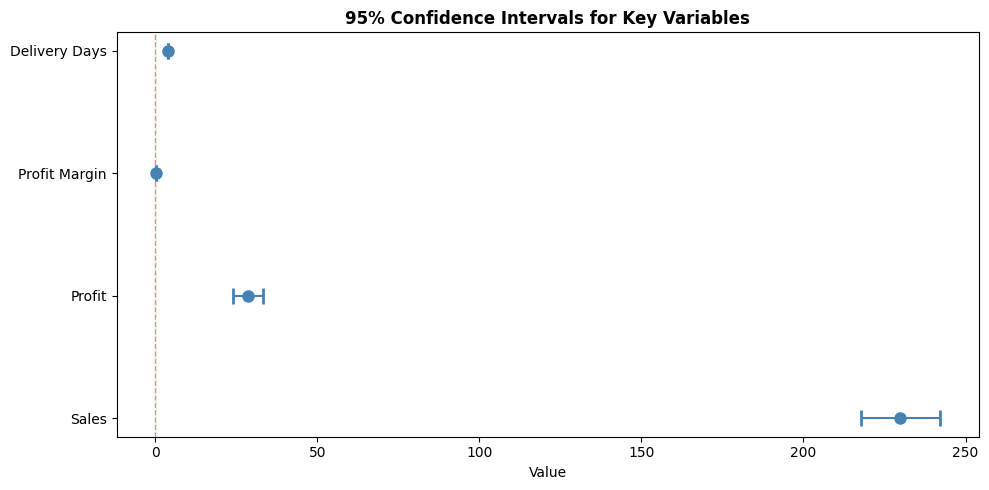

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

results = []
for name, data in variables.items():
    mean, lo, hi = confidence_interval(data)
    results.append({'Variable': name, 'Mean': mean, 'Lower': lo, 'Upper': hi})

ci_df = pd.DataFrame(results)

for i, row in ci_df.iterrows():
    ax.errorbar(row['Mean'], row['Variable'],
                xerr=[[row['Mean'] - row['Lower']], [row['Upper'] - row['Mean']]],
                fmt='o', color='steelblue', capsize=6, capthick=2, markersize=8)

ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('95% Confidence Intervals for Key Variables', fontweight='bold')
ax.set_xlabel('Value')
plt.tight_layout()
plt.savefig('../output/images/03_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

With 95% confidence, the true mean sales per transaction lies between $218 and $242. Despite the substantial variability observed in individual transactions, the large sample size (n = 9,994) results in relatively narrow confidence intervals by reducing the standard error of the mean. The 95% confidence interval for Profit Margin ranges from 11% to 13% and remains entirely positive, indicating that the average transaction is profitable and providing strong evidence of overall profitability at the aggregate business level. Nevertheless, the presence of loss-making transactions elsewhere in the distribution suggests that profitability is not uniform across all orders, products, or customer segments.

#### 3.B. Comparison of Means